# MODULE 4 — CRNN-DF: Discriminative Feature Strategy (Center Loss)
**Requires:** `eeg_data_bundle.pkl` from Module 1

**Goal:** Add center loss on top of the working CRNN backbone.

✅ **Pass criterion:** CRNN-DF test accuracy > CRNN baseline

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
IS_MPS = (device.type == 'mps')
print(f'Device: {device}')

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

with open('eeg_data_bundle.pkl','rb') as f:
    d = pickle.load(f)
X_raw=d['X_raw']; y_enc=d['y_enc']
subjects=d['subjects']; sessions=d['sessions']
S0=d['S0']; S1=d['S1']; CLASSES=d['classes']
print('Data loaded.')


Device: mps
Data loaded.


In [2]:
def zscore(X_tr, X_other):
    mu  = X_tr.mean(axis=(0,2), keepdims=True)
    std = X_tr.std (axis=(0,2), keepdims=True) + 1e-8
    return (X_tr-mu)/std, (X_other-mu)/std

def make_loader(X, y, bs=32, shuffle=True):
    return DataLoader(
        TensorDataset(torch.FloatTensor(X), torch.LongTensor(y)),
        batch_size=bs, shuffle=shuffle, drop_last=True)

def predict(model, X, bs=64):
    model.eval(); preds=[]
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), bs):
            l,_ = model(Xt[i:i+bs].to(device))
            preds.extend(l.argmax(1).cpu().numpy())
    return np.array(preds)

def get_features(model, X, bs=64):
    model.eval(); feats=[]
    Xt = torch.FloatTensor(X)
    with torch.no_grad():
        for i in range(0, len(Xt), bs):
            _,f = model(Xt[i:i+bs].to(device))
            feats.append(f.cpu().numpy())
    return np.vstack(feats)

class CRNN(nn.Module):
    def __init__(self, n_ch=22, n_t=1000, n_cls=4, hidden=64, dropout=0.5):
        super().__init__()
        self.feature_dim  = hidden
        self.spatial_conv = nn.Conv2d(1, 32, kernel_size=(n_ch,45), padding=0)
        self.bn           = nn.BatchNorm2d(32)
        self.relu         = nn.ReLU(inplace=True)
        self.drop_cnn     = nn.Dropout(dropout)
        self.pool         = nn.MaxPool2d((1,75), stride=(1,10))
        lstm_drop = 0.0 if IS_MPS else dropout
        self.lstm         = nn.LSTM(32, hidden, num_layers=2,
                                    batch_first=True, dropout=lstm_drop)
        self.drop_lstm    = nn.Dropout(dropout)
        self.classifier   = nn.Linear(hidden, n_cls)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.drop_cnn(self.relu(self.bn(self.spatial_conv(x))))
        x = self.pool(x)
        x = x.squeeze(2).permute(0,2,1)
        _, (h,_) = self.lstm(x)
        feat = self.drop_lstm(h[-1])
        return self.classifier(feat), feat

# Shape check
_m = CRNN().to(device)
_d = torch.randn(4,22,1000).to(device)
_l, _f = _m(_d)
assert _l.shape == (4,4) and _f.shape == (4,64)
del _m, _d, _l, _f
print('CRNN + helpers defined. ✅')


CRNN + helpers defined. ✅


In [3]:
class CenterLoss(nn.Module):
    """
    Wen et al. 2016 Center Loss — correct implementation.

    Fix over common broken version:
    - Centers are register_buffer (NOT nn.Parameter) — no SGD optimizer needed.
    - Centers updated by closed-form EMA each batch (Wen Eq. 4):
          delta_j = (c_j - mean_feats_j) / (count_j + 1)
          c_j    -= lr_c * delta_j
    - forward() detaches centers so gradients flow to NETWORK ONLY.
    - 30-epoch CE-only warmup lets network stabilise before center loss starts.
    - Centers re-initialised from stable features right after warmup.
    """
    def __init__(self, n_cls=4, feat_dim=64, lr_c=0.5):
        super().__init__()
        self.n_cls = n_cls
        self.lr_c  = lr_c
        self.register_buffer('centers', torch.zeros(n_cls, feat_dim))

    @torch.no_grad()
    def init_from_data(self, model, X, y, bs=64):
        """Eq. 8: set each center = per-class mean feature."""
        model.eval()
        all_f, all_l = [], []
        Xt = torch.FloatTensor(X); yt = torch.LongTensor(y)
        for i in range(0, len(Xt), bs):
            _, f = model(Xt[i:i+bs].to(device))
            all_f.append(f.detach().cpu()); all_l.append(yt[i:i+bs])
        F = torch.cat(all_f); L = torch.cat(all_l)
        for c in range(self.n_cls):
            m = (L == c)
            if m.sum() > 0:
                self.centers[c] = F[m].mean(0).to(self.centers.device)
        model.train()
        dists = [(self.centers[i]-self.centers[j]).norm().item()
                 for i in range(self.n_cls) for j in range(i+1,self.n_cls)]
        print(f'  Centers init. Mean inter-center dist = {np.mean(dists):.3f}')

    @torch.no_grad()
    def update_centers(self, feats, labels):
        """Closed-form EMA — no optimizer, numerically stable."""
        feats = feats.detach(); labels = labels.detach()
        for c in range(self.n_cls):
            mask = (labels == c)
            if mask.sum() == 0: continue
            diff = self.centers[c] - feats[mask].mean(0)
            self.centers[c] -= self.lr_c * diff / (mask.sum().float() + 1)

    @torch.no_grad()
    def expand_inter_class(self, alpha=0.02):
        """Push centers away from global mean (paper Sec. 2.7)."""
        gc = self.centers.mean(0, keepdim=True)
        d  = self.centers - gc
        self.centers.add_(alpha * d / (d.norm(dim=1, keepdim=True) + 1e-8))

    def forward(self, feats, labels):
        c = self.centers[labels].detach()   # detach: gradients to network only
        return torch.mean(torch.norm(feats - c, dim=1))

# Unit test
_cl = CenterLoss(4, 64)
_f  = torch.randn(8, 64, requires_grad=True)
_l  = torch.randint(0, 4, (8,))
_loss = _cl(_f, _l); _loss.backward()
assert _f.grad is not None
_cl.update_centers(_f, _l)
print(f'CenterLoss unit test: loss={_loss.item():.4f}  ✅')
del _cl, _f, _l, _loss


CenterLoss unit test: loss=7.5905  ✅


In [4]:
def train_baseline(X_tr, y_tr, n_epochs=150):
    """Plain CE, no center loss."""

    model = CRNN().to(device)
    opt   = optim.Adam(model.parameters(), lr=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=1e-6)
    ce    = nn.CrossEntropyLoss()
    loader= make_loader(X_tr, y_tr)
    hist  = {'ce':[], 'train_acc':[]}

    for ep in range(1, n_epochs+1):
        model.train()
        tot, cor, tot_n = 0.0, 0, 0
        for Xb,yb in loader:
            Xb,yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits,_ = model(Xb)
            loss = ce(logits,yb); loss.backward(); opt.step()
            tot += loss.item()
            cor += (logits.argmax(1)==yb).sum().item()
            tot_n += yb.size(0)
        sched.step()
        hist['ce'].append(tot/len(loader))
        hist['train_acc'].append(100*cor/tot_n)
        if ep % 30 == 0:
            print(f'  ep {ep:3d}  CE={hist["ce"][-1]:.4f}  train={hist["train_acc"][-1]:.1f}%')
    return model, hist


def train_crnn_df(X_tr, y_tr, n_epochs=150, lam=0.1, warmup=30):
    """CE + center loss with warmup + EMA center updates."""

    model = CRNN().to(device)
    closs = CenterLoss().to(device)
    opt   = optim.Adam(model.parameters(), lr=1e-4)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=1e-6)
    ce    = nn.CrossEntropyLoss()
    loader= make_loader(X_tr, y_tr)
    hist  = {'ce':[], 'cen':[], 'train_acc':[]}

    for ep in range(1, n_epochs+1):
        # Re-init centers from stable features right after warmup
        if ep == warmup + 1:
            print(f'  [ep {ep}] Warmup done — re-init centers from features')
            closs.init_from_data(model, X_tr, y_tr)

        use_c = (ep > warmup)
        model.train()
        tot_ce, tot_cen, cor, tot_n = 0.0, 0.0, 0, 0

        for Xb,yb in loader:
            Xb,yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            logits, feats = model(Xb)
            l_ce = ce(logits, yb)
            if use_c:
                l_cen = closs(feats, yb)
                loss  = l_ce + lam * l_cen
                closs.update_centers(feats, yb)
            else:
                l_cen = torch.tensor(0.0)
                loss  = l_ce
            loss.backward(); opt.step()
            tot_ce  += l_ce.item()
            tot_cen += l_cen.item()
            cor     += (logits.argmax(1)==yb).sum().item()
            tot_n   += yb.size(0)

        sched.step()
        if use_c and ep % 15 == 0:
            closs.expand_inter_class(alpha=0.02)

        hist['ce'].append(tot_ce/len(loader))
        hist['cen'].append(tot_cen/len(loader))
        hist['train_acc'].append(100*cor/tot_n)

        if ep % 30 == 0:
            phase = 'center' if use_c else 'warmup'
            print(f'  ep {ep:3d} [{phase:6s}]  CE={hist["ce"][-1]:.4f}  '
                  f'Cen={hist["cen"][-1]:.4f}  train={hist["train_acc"][-1]:.1f}%')

    return model, closs, hist

print('Training functions defined. ✅')


Training functions defined. ✅


In [5]:
TEST_SUBJ = '1'
m_tr = subjects != TEST_SUBJ
m_te = (subjects == TEST_SUBJ) & (sessions == S1)
X_tr_n, X_te_n = zscore(X_raw[m_tr], X_raw[m_te])
y_tr = y_enc[m_tr]; y_te = y_enc[m_te]
print(f'Train: {X_tr_n.shape}  Test: {X_te_n.shape}')

print('\n=== Baseline CRNN (no center loss) ===')
model_base, hist_base = train_baseline(X_tr_n, y_tr)
preds_base = predict(model_base, X_te_n)
base_acc   = accuracy_score(y_te, preds_base) * 100
print(f'Baseline test acc: {base_acc:.2f}%')

print('\n=== CRNN-DF (center loss, λ=0.1, warmup=30) ===')
model_df, closs, hist_df = train_crnn_df(X_tr_n, y_tr, lam=0.1, warmup=30)
preds_df = predict(model_df, X_te_n)
df_acc   = accuracy_score(y_te, preds_df) * 100
print(f'CRNN-DF test acc : {df_acc:.2f}%')
print(f'Improvement      : {df_acc - base_acc:+.2f}%')


Train: (4608, 22, 1000)  Test: (288, 22, 1000)

=== Baseline CRNN (no center loss) ===
  ep  30  CE=1.1076  train=50.9%
  ep  60  CE=0.9104  train=61.5%
  ep  90  CE=0.7919  train=68.3%
  ep 120  CE=0.7171  train=71.7%
  ep 150  CE=0.6992  train=72.5%
Baseline test acc: 34.38%

=== CRNN-DF (center loss, λ=0.1, warmup=30) ===
  ep  30 [warmup]  CE=1.1093  Cen=0.0000  train=50.8%
  [ep 31] Warmup done — re-init centers from features
  Centers init. Mean inter-center dist = 0.704
  ep  60 [center]  CE=0.9420  Cen=1.4320  train=61.8%
  ep  90 [center]  CE=0.7979  Cen=1.4304  train=67.9%
  ep 120 [center]  CE=0.7259  Cen=1.4432  train=71.5%
  ep 150 [center]  CE=0.6931  Cen=1.4527  train=73.6%
CRNN-DF test acc : 46.88%
Improvement      : +12.50%


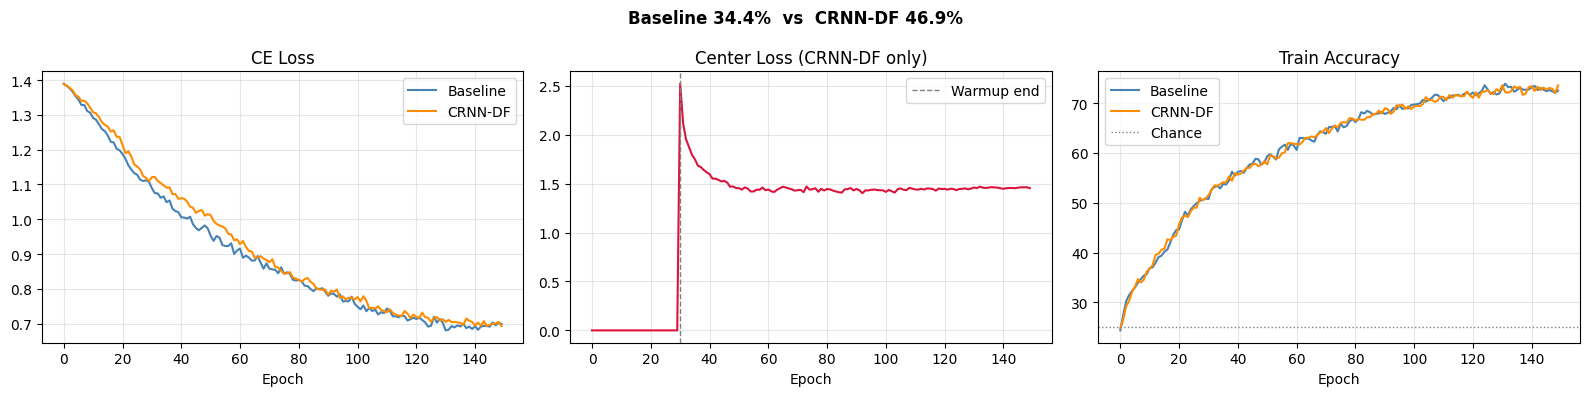

Running t-SNE...


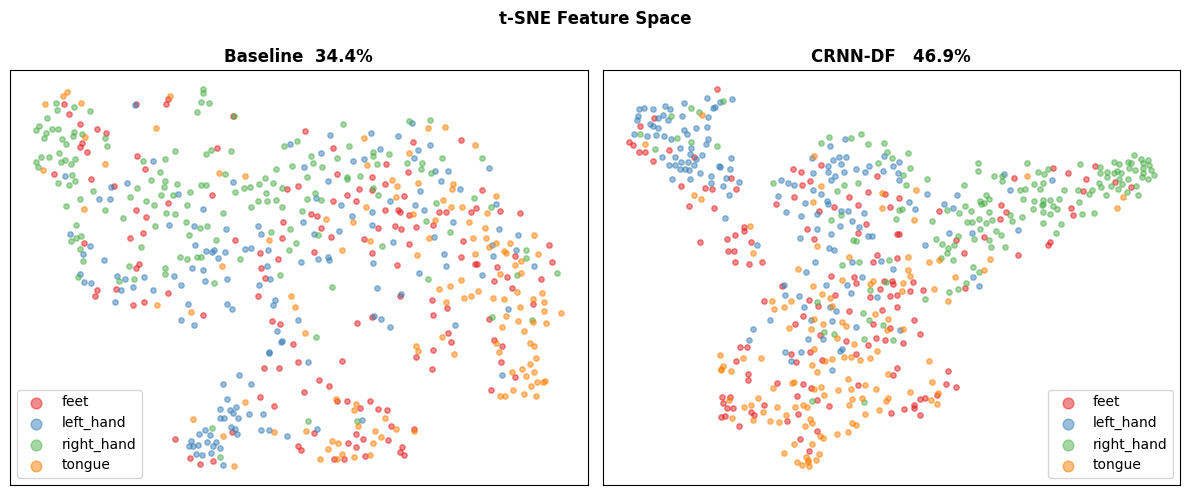

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(hist_base['ce'], color='steelblue',  label='Baseline')
axes[0].plot(hist_df['ce'],   color='darkorange', label='CRNN-DF')
axes[0].set_title('CE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_xlabel('Epoch')

axes[1].plot(hist_df['cen'], color='crimson')
axes[1].axvline(30, color='gray', ls='--', lw=1, label='Warmup end')
axes[1].set_title('Center Loss (CRNN-DF only)')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(hist_base['train_acc'], color='steelblue',  label='Baseline')
axes[2].plot(hist_df['train_acc'],   color='darkorange', label='CRNN-DF')
axes[2].axhline(25, color='gray', ls=':', lw=1, label='Chance')
axes[2].set_title('Train Accuracy'); axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_xlabel('Epoch')

plt.suptitle(f'Baseline {base_acc:.1f}%  vs  CRNN-DF {df_acc:.1f}%', fontweight='bold')
plt.tight_layout()
plt.savefig('m4_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# t-SNE
print('Running t-SNE...')
n_viz = min(600, len(X_tr_n))
idx_v = np.random.choice(len(X_tr_n), n_viz, replace=False)
y_viz = y_tr[idx_v]
F_base = get_features(model_base, X_tr_n[idx_v])
F_df   = get_features(model_df,   X_tr_n[idx_v])

tsne   = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
F2b    = tsne.fit_transform(F_base)
tsne2  = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
F2df   = tsne2.fit_transform(F_df)

colors = ['#e41a1c','#377eb8','#4daf4a','#ff7f00']
fig, axes = plt.subplots(1,2,figsize=(12,5))
for cls in range(4):
    m = y_viz==cls
    axes[0].scatter(F2b[m,0],  F2b[m,1],  c=colors[cls], alpha=0.5, s=15, label=CLASSES[cls])
    axes[1].scatter(F2df[m,0], F2df[m,1], c=colors[cls], alpha=0.5, s=15, label=CLASSES[cls])
axes[0].set_title(f'Baseline  {base_acc:.1f}%', fontweight='bold')
axes[1].set_title(f'CRNN-DF   {df_acc:.1f}%',  fontweight='bold')
for ax in axes: ax.legend(markerscale=2); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle('t-SNE Feature Space', fontweight='bold')
plt.tight_layout()
plt.savefig('m4_tsne.png', dpi=120, bbox_inches='tight')
plt.show()


In [7]:
print('='*50)
print(f'Baseline CRNN : {base_acc:.2f}%')
print(f'CRNN-DF       : {df_acc:.2f}%')
print(f'Improvement   : {df_acc-base_acc:+.2f}%')
print(f'Chance        : 25%')
print('='*50)

assert df_acc > 40, (
    f'FAIL: CRNN-DF {df_acc:.1f}% still near chance — center loss still hurting.')
assert df_acc >= base_acc - 3, (
    f'FAIL: CRNN-DF ({df_acc:.1f}%) much worse than baseline ({base_acc:.1f}%). λ too high?')

print('\n✅  MODULE 4 PASS')
torch.save(model_df.state_dict(), 'crnn_df_subj1.pt')
print('Saved crnn_df_subj1.pt → ready for Module 5')


Baseline CRNN : 34.38%
CRNN-DF       : 46.88%
Improvement   : +12.50%
Chance        : 25%

✅  MODULE 4 PASS
Saved crnn_df_subj1.pt → ready for Module 5
